# Bayesian Flow Networks cho MNIST rời rạc
Trong notebook này, chúng ta sẽ thực hành cách sử dụng [Bayesian Flow Networks](https://arxiv.org/abs/2308.07037) (BFN) để tạo ra các mẫu ảnh tương tự như dữ liệu từ tập MNIST đã được rời rạc hóa.

**Giải thích từ paper:** BFN là một lớp mô hình sinh mới (generative models) không dựa trên việc đảo ngược quá trình khuếch tán (diffusion), mà dựa trên việc cập nhật liên tục các tham số của một phân phối Bayes (Bayesian updating) thông qua các thông điệp nhiễu (noisy messages).

## Khai báo thư viện
Notebook này sử dụng module Pytorch EMA (Exponential Moving Average). Nếu bạn chưa cài đặt, hãy chạy lệnh sau:
```bash
pip install torch-ema
```

In [ ]:
import os
import random
from math import inf

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_ema
import torchvision
import torchvision.transforms as transforms
from torch.nn.functional import relu
from torch.optim import AdamW
from torchsummary import summary
from tqdm.auto import tqdm

## Mã nguồn bổ trợ (Preliminary code)
Trong phần này, chúng ta định nghĩa các biến và hàm tiện ích sẽ được sử dụng xuyên suốt notebook.

Cấu hình các biến toàn cục cho notebook:
- `DATAPATH`: Đường dẫn lưu trữ bộ dữ liệu.
- `SEED`: Seed ngẫu nhiên để đảm bảo tính tái lập (reproducibility).
- `DEVICE`: Thiết bị tính toán (`cpu` hoặc `cuda`).
- `SAVE_MODEL`: Nếu là `True`, mô hình sẽ được lưu sau khi train hoặc tải lại nếu đã tồn tại.
- `MODELS_PATH`: Thư mục lưu trữ trọng số mô hình.

In [ ]:
DATAPATH = "./data/"
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_MODEL = True
MODELS_PATH = "./models/"

In [ ]:
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
%matplotlib inline

"""
Publication ready pyplot theme
Source: https://github.com/matplotlib/matplotlib/issues/19028
"""

plot_settings = {'ytick.labelsize': 16,
                 'xtick.labelsize': 16,
                 'font.size': 22,
                 'figure.figsize': (10, 5),
                 'axes.titlesize': 22,
                 'axes.labelsize': 18,
                 'lines.linewidth': 2,
                 'lines.markersize': 3,
                 'legend.fontsize': 11,
                 'mathtext.fontset': 'stix',
                 'font.family': 'STIXGeneral'}
plt.style.use(plot_settings)

In [ ]:
if SEED:
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.use_deterministic_algorithms(True)

In [ ]:
def get_sample(dataloader: torch.utils.data.DataLoader) -> tuple[torch.Tensor, int]:
    """
    Lấy 1 sample ngẫu nhiên từ DataLoader.

    Trong context BFN / generative modeling:
    - image: x ∈ {0,1,...,K-1}^{H×W}
    - label: không quan trọng trong generative task,
      nhưng vẫn giữ để debug dataset (MNIST, CIFAR,...)

    Args:
        dataloader: tập dữ liệu huấn luyện

    Returns:
        (image, label)
    """

    # DataLoader Python iterator → lấy batch đầu tiên
    # (không thực sự random chuẩn, nhưng đủ cho visualization)
    for sample in dataloader:
        return sample[0], sample[1][0].numpy()

    # nếu dataloader rỗng → lỗi
    raise IndexError("Could not sample an empty data loader.")

def show_samples(
    dataloader: torch.utils.data.DataLoader,
    n: int,
    title: str = None
) -> None:
    """
    Hiển thị n ảnh random từ dataset.

    Mục đích trong context paper:
    - kiểm tra distribution dữ liệu thật x
    - sanity check trước khi train BFN / diffusion model
    """

    fig, ax = plt.subplots(1, n, figsize=(3*n, 3))

    for i in range(n):

        # lấy 1 sample từ dataset
        img, label = get_sample(dataloader)

        # img shape thường: (C, H, W)
        # lấy channel đầu tiên để visualize grayscale
        ax[i].imshow(
            img[0][0],
            cmap='Greys_r',
            interpolation='nearest'
        )

        ax[i].set_title(label)
        ax[i].axis("off")

    title = title if title else f"{n} random samples"

    fig.suptitle(
        title,
        position=(0.5, 1.1)
    )

def moving_average(
    data: list[float],
    window_size: int = 20
) -> list[float]:
    """
    Smooth loss curve / metric curve.

    Trong training BFN:
    - loss L∞ có noise cao vì:
        + sample t ~ Uniform(0,1)
        + Gaussian noise y
        + stochastic sampling k

    → nên curve rất nhiễu

    moving average giúp:
    - nhìn trend hội tụ rõ hơn
    - giảm variance visualization
    """

    moving_avg = []

    # sliding window average
    for i in range(len(data) - window_size + 1):

        window = data[i : i + window_size]

        avg = sum(window) / window_size

        moving_avg.append(avg)

    return moving_avg

## Nhập dữ liệu (Data import)
Phần này định nghĩa code để tải và rời rạc hóa (discretize) MNIST.

**Lưu ý:** BFN hoạt động cực hiệu quả trên dữ liệu rời rạc (như ảnh đen trắng 0/1) bằng cách xử lý các tham số của phân phối Categorical thay vì xử lý trực tiếp pixel liên tục.

In [ ]:
# Define the data transformation
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize((0.5,), (0.5,)),  # Normalize the pixel values to [-1, 1]
    #transforms.Lambda(lambda x: torch.round((x + 1) / 2).to(torch.int64)) # Discretize data
])

# Download and load the MNIST dataset
train_dataset = torchvision.datasets.MNIST(root=DATAPATH, train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root=DATAPATH, train=False, transform=transform, download=True)

# Create data loaders
batch_size = 64
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class DynamicallyBinarizedMNIST(torchvision.datasets.MNIST):
    """
    MNIST nhưng được giữ dạng ảnh grayscale gốc,
    và sẽ binarize "on-the-fly" (dynamic binarization).

    Ý nghĩa trong generative modeling:

    - thay vì cố định ảnh nhị phân
    - mỗi lần lấy sample sẽ random threshold khác nhau

    → giúp model thấy nhiều dạng noise hơn
    → giảm overfitting vào threshold cố định
    """

    def __init__(
        self,
        root,
        train=True,
        transform=None,
        target_transform=None,
        download=False
    ):
        super().__init__(
            root,
            train=train,
            transform=transform,
            target_transform=target_transform,
            download=download
        )

    def __getitem__(self, index):
        # lấy ảnh gốc MNIST (0–255 hoặc float 0–1 tùy transform)
        img, target = self.data[index], int(self.targets[index])

        # apply transform nếu có (normalize, toTensor,...)
        if self.transform is not None:
            img = self.transform(img)

        # trả về ảnh + label
        return img, target

def collate_dynamic_binarize(
    batch: list[tuple[torch.Tensor, int]]
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Đây là phần quan trọng nhất của toàn pipeline.

    Nó biến MNIST từ:
        continuous grayscale image (0→1)

    thành:
        discrete binary image (0/1)

    nhưng KHÔNG cố định,
    mà random mỗi batch.
    """

    images, targets = zip(*batch)

    # mỗi image trong batch có 1 threshold riêng
    # → đây là "dynamic binarization"
    binarization_probs = torch.rand(len(images))

    binarized_images = []

    for img, prob in zip(images, binarization_probs):

        # pixel-wise Bernoulli thresholding:
        #
        # nếu pixel > prob → 1
        # else → 0
        binarized_img = (img > prob).float()

        binarized_images.append(binarized_img)

    # shape:
    # (B, 1, H, W)
    #
    # convert sang int64 vì BFN coi là categorical index
    return (
        torch.stack(binarized_images)[:, None, ...].to(torch.int64),
        torch.tensor(targets)
    )

# Create the dynamically binarized MNIST dataset
train_dataset = DynamicallyBinarizedMNIST(root=DATAPATH, train=True, download=True) # transform=transform
test_dataset = DynamicallyBinarizedMNIST(root=DATAPATH, train=False, download=True) # transform=transform

# Create data loaders with the collate function
batch_size = 512
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_dynamic_binarize)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_dynamic_binarize)


Number of data points in the training dataset: 118
Number of data points in the training dataset: 20


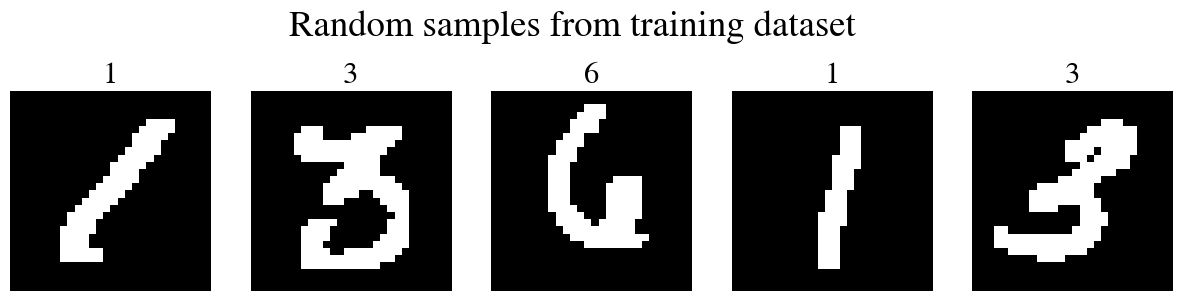

In [ ]:
print(f"Number of data points in the training dataset: {len(train_loader)}")
print(f"Number of data points in the training dataset: {len(test_loader)}")
show_samples(train_loader, 5, "Random samples from training dataset")

## Định nghĩa mô hình

### Mô hình trung gian (Intermediary model)
Chúng ta bắt đầu với một kiến trúc Convolutional. Ở đây sử dụng một phiên bản rút gọn của [U-Net](http://arxiv.org/abs/1505.04597) để làm backbone (mạng xương sống) dự đoán các tham số phân phối.

In [ ]:
C = 128

class UNet(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, dropout: float=0.3):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels

        # Encoder
        # input: 28x28xIN
        self.e11 = nn.Conv2d(in_channels, C//2, kernel_size=3, padding=1) # output: 28x28xC//2
        self.dpe11 = nn.Dropout(p=dropout)
        self.e12 = nn.Conv2d(C//2, C//2, kernel_size=3, padding=1) # output: 28x28xC//2
        self.dpe12 = nn.Dropout(p=dropout)
        self.e13 = nn.Conv2d(C//2, C//2, kernel_size=3, padding=1) # output: 28x28xC//2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # output: 14x14xC//2

        # input: 14x14xC//2
        self.e21 = nn.Conv2d(C//2, C, kernel_size=3, padding=1) # output: 14x14xC
        self.dpe21 = nn.Dropout(p=dropout)
        self.e22 = nn.Conv2d(C, C, kernel_size=3, padding=1) # output: 14x14xC
        self.dpe22 = nn.Dropout(p=dropout)
        self.e23 = nn.Conv2d(C, C, kernel_size=3, padding=1) # output: 28x28xC
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # output: 7x7xC

        # input: 7x7xC
        self.e31 = nn.Conv2d(C, 2*C, kernel_size=3, padding=1) # output: 7x7x2*C
        self.dpe31 = nn.Dropout(p=dropout)
        self.e32 = nn.Conv2d(2*C, 2*C, kernel_size=3, padding=1) # output: 7x7x2*C
        self.dpe32 = nn.Dropout(p=dropout)
        self.e33 = nn.Conv2d(2*C, 2*C, kernel_size=3, padding=1) # output: 7x7xC

        # Decoder
        # input: 7x7x2*C
        self.upconv1 = nn.ConvTranspose2d(2*C, C, kernel_size=2, stride=2) # output: 14x14xC
        self.d11 = nn.Conv2d(2*C, C, kernel_size=3, padding=1) # output: 14x14xC
        self.dpd11 = nn.Dropout(p=dropout)
        self.d12 = nn.Conv2d(C, C, kernel_size=3, padding=1) # output: 14x14xC
        self.dpd12 = nn.Dropout(p=dropout)
        self.d13 = nn.Conv2d(C, C, kernel_size=3, padding=1) # output: 14x14xC

        # input: 14x14x2*C
        self.upconv2 = nn.ConvTranspose2d(C, C//2, kernel_size=2, stride=2) # output: 28x28x7
        self.d21 = nn.Conv2d(C, C//2, kernel_size=3, padding=1) # output: 28x28xC//2
        self.dpd21 = nn.Dropout(p=dropout)
        self.d22 = nn.Conv2d(C//2, C//2, kernel_size=3, padding=1) # output: 28x28xC//2
        self.dpd22 = nn.Dropout(p=dropout)
        self.d23 = nn.Conv2d(C//2, C//2, kernel_size=3, padding=1) # output: 28x28xC//2

        # Output layer
        # input: 28x28xC//2
        self.outconv = nn.Conv2d(C//2, out_channels, kernel_size=1) # output: 28x28xOUT

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Performs a forward pass on the model.

        Args:
            x (torch.Tensor): input data.

        Returns:
            torch.Tensor: output data.
        """
        # Encode the input data
        xe11 = self.dpe11(relu(self.e11(x)))
        xe12 = self.dpe12(relu(self.e12(xe11)))
        xe13 = relu(self.e13(xe12))
        xp1 = self.pool1(xe11)

        xe21 = self.dpe21(relu(self.e21(xp1)))
        xe22 = self.dpe22(relu(self.e22(xe21)))
        xe23 = relu(self.e23(xe22))
        xp2 = self.pool2(xe23)

        xe31 = self.dpe31(relu(self.e31(xp2)))
        xe32 = self.dpe32(relu(self.e32(xe31)))
        xe33 = relu(self.e33(xe32))

        # Decode the computed encoding
        xu11 = self.upconv1(xe33)
        xu12 = torch.cat([xu11, xe23], dim=1)
        xd11 = self.dpd11(relu(self.d11(xu12)))
        xd12 = self.dpd12(relu(self.d12(xd11)))
        xd13 = relu(self.d13(xd12))

        xu21 = self.upconv2(xd13)
        xu22 = torch.cat([xu21, xe13], dim=1)
        xd21 = self.dpd21(relu(self.d21(xu22)))
        xd22 = self.dpd22(relu(self.d22(xd21)))
        xd23 = relu(self.d23(xd22))

        # Output layer
        out = self.outconv(xd23)
        return out

## Bayesian Flow Network
Định nghĩa lớp bao phủ BFN cho dữ liệu 2D.

**Cơ chế hoạt động:** Thay vì học score-matching như Diffusion, BFN học cách ánh xạ từ một phân phối input $\theta$ (được biểu diễn dưới dạng simplex) và thời gian $t$ sang một phân phối output $p_O$ dự đoán giá trị gốc của dữ liệu.

In [ ]:
class BayesianFlowNetwork2D(nn.Module):
    """
    Bayesian Flow Network cho dữ liệu 2D (ví dụ ảnh hoặc grid D×D).

    Đây là mở rộng của BFN discrete case sang structured data (giống image).

    Theo paper BFN:
    - θ là input distribution p_I(x | θ)
    - network học p_O(k | θ, t)
    - training dùng continuous-time loss L∞ (Algorithm 8)
    """

    def __init__(self, network, D, K, beta=3.0):
        super(BayesianFlowNetwork2D, self).__init__()

        # β(1) trong paper (scale của noise process)
        self.beta = beta

        # kích thước không gian (ví dụ image D×D)
        self.D = D

        # số class mỗi pixel
        self.K = K

        # backbone network Ψ(θ, t)
        self.network = network

    def forward(
        self,
        theta: torch.Tensor,
        t: torch.Tensor,
        ema: torch_ema.ExponentialMovingAverage
    ) -> torch.Tensor:
        """
        Forward pass của Ψ(θ, t).

        Theo paper (Eq. về output network):
            Ψ maps (θ, t) → logits over K classes per position
        """

        # scale θ từ [0,1] → [-1,1]
        # (giúp ổn định khi đưa vào MLP/CNN)
        theta = (theta * 2) - 1

        # đổi trục để đưa time channel vào đúng chiều spatial
        # từ (B, D, D, K) → (B, K, D, D)
        theta = torch.transpose(theta, 1, 3)

        # thêm time embedding trực tiếp vào input
        # t broadcast thành channel constant
        #
        # Ý tưởng này tương đương conditioning Ψ(θ, t)
        # trong continuous-time formulation của BFN
        if ema is not None:
            with ema.average_parameters():
                output = self.network(
                    theta + t[:, None, None, None]
                )
        else:
            output = self.network(
                theta + t[:, None, None, None]
            )

        # trả lại shape (B, D, D, K)
        return torch.transpose(output, 1, 3)

    def discrete_output_distribution(
        self,
        theta: torch.Tensor,
        t: torch.Tensor,
        ema: torch_ema.ExponentialMovingAverage = None
    ) -> torch.Tensor:
        """
        Tính p_O(k | θ, t)

        Theo paper:
            p_O = softmax(Ψ(θ, t))   (multi-class case)

            hoặc sigmoid nếu K = 2
        """

        output = self.forward(theta, t, ema=ema)

        # binary case (K=2)
        if self.K == 2:
            # p(k=1 | θ,t)
            p0_1 = torch.sigmoid(output)

            # p(k=0)
            p0_2 = 1 - p0_1

            p0 = torch.cat((p0_1, p0_2), dim=-1)

        else:
            # Eq. softmax trong BFN discrete formulation
            p0 = torch.nn.functional.softmax(output, dim=-1)

        return p0

    def process(
        self,
        x: torch.Tensor,
        time: float = None,
        training: bool = True
    ):
        """
        Training step (Algorithm 8 - BFN discrete case mở rộng sang 2D)

        Ý tưởng:

        - x là dữ liệu rời rạc (image/grid)
        - one-hot hóa từng pixel
        - thêm Gaussian noise theo β(t)
        - tạo θ noisy
        - network dự đoán p_O
        - tính L∞ loss
        """

        # ======================================================
        # STEP 1: sample time t ~ Uniform(0,1)
        # ======================================================
        t = (
            torch.tensor(time, device=x.device)[None]
            if time is not None
            else torch.rand(
                (x.size(0),),
                device=x.device,
                dtype=torch.float32
            )
        )

        # ======================================================
        # STEP 2: β(t) = β(1) * t²
        # (đúng theo continuous-time formulation trong paper)
        # ======================================================
        beta = self.beta * (t ** 2)

        # ======================================================
        # STEP 3: one-hot encode dữ liệu rời rạc
        #
        # x → e_x ∈ {0,1}^(B×D×D×K)
        #
        # Đây là embedding của categorical data
        # ======================================================
        one_hot_x = F.one_hot(
            x.permute(0, 2, 3, 1).to(torch.int64),
            num_classes=self.K
        ).float().squeeze()

        # ======================================================
        # STEP 4: Gaussian corruption process (BFN core)
        #
        # y ~ N( β(t) (K e_x - 1), β(t) K I )
        #
        # Đây là step quan trọng nhất của Algorithm 8
        # ======================================================
        mean = beta[:, None, None, None] * (
            self.K * one_hot_x - 1
        )

        std = (beta * self.K)[:, None, None, None].sqrt()

        eps = torch.randn_like(mean)

        y = mean + std * eps

        # ======================================================
        # STEP 5: convert noisy signal → simplex θ
        #
        # θ = softmax(y)
        #
        # Đây chính là "input distribution p_I"
        # ======================================================
        theta = F.softmax(y, dim=-1)

        # ======================================================
        # STEP 6: network prediction p_O
        # ======================================================
        p_0 = self.discrete_output_distribution(theta, t)

        e_x = one_hot_x

        # prediction expectation ê(θ,t)
        e_hat = p_0

        # ======================================================
        # STEP 7: continuous-time loss L∞ (Algorithm 8)
        #
        # L∞ = K β(1) t || e_x - e_hat ||²
        #
        # Đây là loss chính của BFN (không phải CE loss)
        # ======================================================
        L_infinity = (
            self.K
            * self.beta
            * t[:, None, None, None]
            * ((e_x - e_hat) ** 2)
        )

        if training:
            return L_infinity.mean()

        # inference mode
        else:
            k = torch.distributions.Categorical(
                probs=p_0
            ).sample()

            return L_infinity.mean(), y, k, t

    @torch.inference_mode()
    def sample(
        self,
        batch_size: int = 128,
        nb_steps: int = 10,
        ema: torch_ema.ExponentialMovingAverage = None,
        device: str = 'cpu'
    ):
        """
        Sampling theo Algorithm 9 (BFN generation process)

        Ý tưởng:

        1. bắt đầu từ prior uniform θ = 1/K
        2. lặp nhiều bước:
            - network dự đoán p_O
            - sample k
            - tạo Gaussian message y
            - update posterior θ
        """

        self.eval()

        # ======================================================
        # PRIOR: θ₀ = uniform
        # ======================================================
        theta = torch.ones(
            (batch_size, self.D, self.D, self.K),
            device=device
        ) / self.K

        t = torch.zeros(
            (theta.shape[0]),
            device=theta.device,
            dtype=theta.dtype
        )

        for i in tqdm(range(1, nb_steps + 1)):

            # continuous time schedule
            t = (i - 1) / nb_steps
            t = t * torch.ones(
                (theta.shape[0]),
                device=theta.device,
                dtype=theta.dtype
            )

            # ==================================================
            # STEP 1: sample category from model
            # k ~ p_O(k | θ, t)
            # ==================================================
            k_probs = self.discrete_output_distribution(
                theta,
                t,
                ema=ema
            )

            k = torch.distributions.Categorical(
                probs=k_probs
            ).sample()

            # ==================================================
            # STEP 2: noise scale α_i
            #
            # α = β(1) * (2i - 1) / n²
            #
            # đúng theo Algorithm 9 trong paper
            # ==================================================
            alpha = (
                self.beta
                * (2 * i - 1)
                / (nb_steps ** 2)
            )

            e_k = F.one_hot(
                k,
                num_classes=self.K
            ).float()

            # ==================================================
            # STEP 3: Gaussian message
            #
            # y ~ N( α (K e_k - 1), α K I )
            # ==================================================
            mean = alpha * (self.K * e_k - 1)

            var = alpha * self.K

            std = torch.full_like(
                mean,
                fill_value=var
            ).sqrt()

            eps = torch.randn_like(e_k)

            y = mean + std * eps

            # ==================================================
            # STEP 4: Bayesian update
            #
            # θ' = exp(y) * θ
            # normalize → posterior simplex
            #
            # Đây chính là core inference rule của BFN
            # ==================================================
            theta_prime = torch.exp(y) * theta

            theta = theta_prime / theta_prime.sum(
                -1,
                keepdim=True
            )

        # ======================================================
        # FINAL SAMPLE at t = 1
        # ======================================================
        k_probs_final = self.discrete_output_distribution(
            theta,
            torch.ones_like(t),
            ema=ema
        )

        k_final = torch.distributions.Categorical(
            probs=k_probs_final
        ).sample()

        return k_final

In [ ]:
unet = UNet(2, 1, dropout=0.5)
bfn = BayesianFlowNetwork2D(network=unet, D=28, K=2).to(DEVICE)
ema = torch_ema.ExponentialMovingAverage(bfn.network.parameters(), decay=0.9999)
ema.to(DEVICE)



### Huấn luyện mô hình
Các tham số quan trọng:
- `EPOCHS`: Số lượt huấn luyện tối đa.
- `EARLY_STOPPING`: Dừng sớm nếu loss không cải thiện.
- `PATIENCE`: Số bước chờ trước khi dừng sớm.
- `LEARNING_RATE`: Tốc độ học của optimizer.

In [ ]:
EPOCHS = 100
EARLY_STOPPING = False
PATIENCE = 1e6
LEARNING_RATE = 3e-4

Sau đó, chúng ta tiến hành huấn luyện BFN trên dữ liệu đã chuẩn bị.

In [ ]:
optim = AdamW(bfn.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.98), weight_decay=0.01)

In [ ]:
def train_model(model: BayesianFlowNetwork2D, optimizer: torch.optim.Optimizer) -> list[float]:
  """
  Train a BFN model, given an optimizer.

  Args:
      model (BayesianFlowNetwork2D)
      optimizer (torch.optim.Optimizer)

  Returns:
      list[float]: training losses.
  """
  bfn_path = MODELS_PATH + "mnist_bfn.pt"
  if SAVE_MODEL:
    if os.path.exists(bfn_path):
      checkpoint = torch.load(bfn_path)
      model.load_state_dict(checkpoint['model_state_dict'])
      print(f"Trained model found, training process skipped. To train a new model, remove the file {bfn_path}.")
      return checkpoint["training_losses"]
  losses = []
  best_loss = inf
  k = 0
  stop = EARLY_STOPPING
  i = 0
  for i in range(EPOCHS):
    for X, _ in tqdm(train_loader, desc=f"Epoch {i+1}/{EPOCHS}"):
        optimizer.zero_grad()
        loss = model.process(X.to(DEVICE))
        loss.backward()
        optimizer.step()
        ema.update()
        losses.append(loss.item())
        if loss.item() < best_loss:
          best_loss = loss.item()
          k = 0
        else:
          k += 1
          if k == PATIENCE:
            k = 0
            stop = True
            print("Patience value has been reached, ending training process.")
            break
    if stop:
      break
  print(f"Model trained in {i+1} epochs.")
  if SAVE_MODEL:
    torch.save({"model_state_dict": model.state_dict(), "training_losses": losses}, bfn_path)
    print(f"Trained model saved at {bfn_path}")
  return losses

In [ ]:
training_losses = train_model(bfn, optim)

Epoch 1/100:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 2/100:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 3/100:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 4/100:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 5/100:   0%|          | 0/118 [00:00<?, ?it/s]

...

Epoch 97/100:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 98/100:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 99/100:   0%|          | 0/118 [00:00<?, ?it/s]

Epoch 100/100:   0%|          | 0/118 [00:00<?, ?it/s]

Model trained in 100 epochs.
Trained model saved at ./models/mnist_bfn.pt


Sau khi huấn luyện, chúng ta có thể quan sát sự tiến hóa của hàm mất mát (loss function). Trong BFN, ta thường tối ưu hóa $L_{\infty}$ (continuous-time loss), giúp mô hình học cách giảm độ bất định của phân phối Bayes theo thời gian.

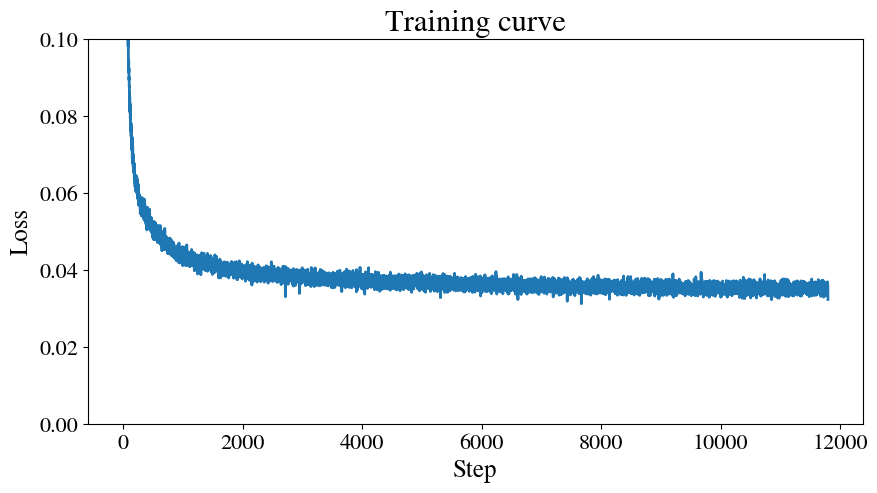

In [ ]:
plt.plot(training_losses)
plt.title("Training curve")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.ylim(0, 0.1);

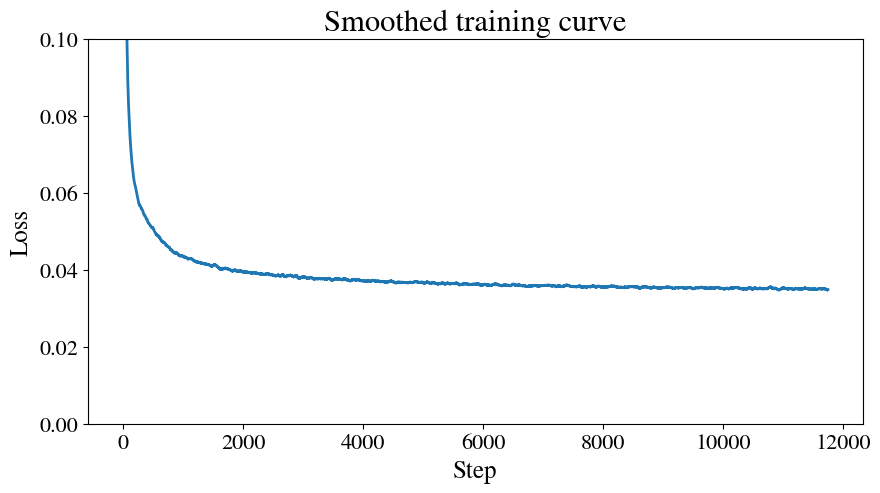

In [ ]:
plt.plot(moving_average(training_losses, 50))
plt.title("Smoothed training curve")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.ylim(0, 0.1);

### Khởi tạo mẫu (Sample generation)

Bây giờ chúng ta sẽ tạo ra các hình ảnh mới từ nhiễu trắng bằng quy trình lấy mẫu lặp (Iterative Sampling).

In [ ]:
x_hat = bfn.sample(device=DEVICE.type, nb_steps=1000, batch_size=16, ema=ema)

  0%|          | 0/1000 [00:00<?, ?it/s]

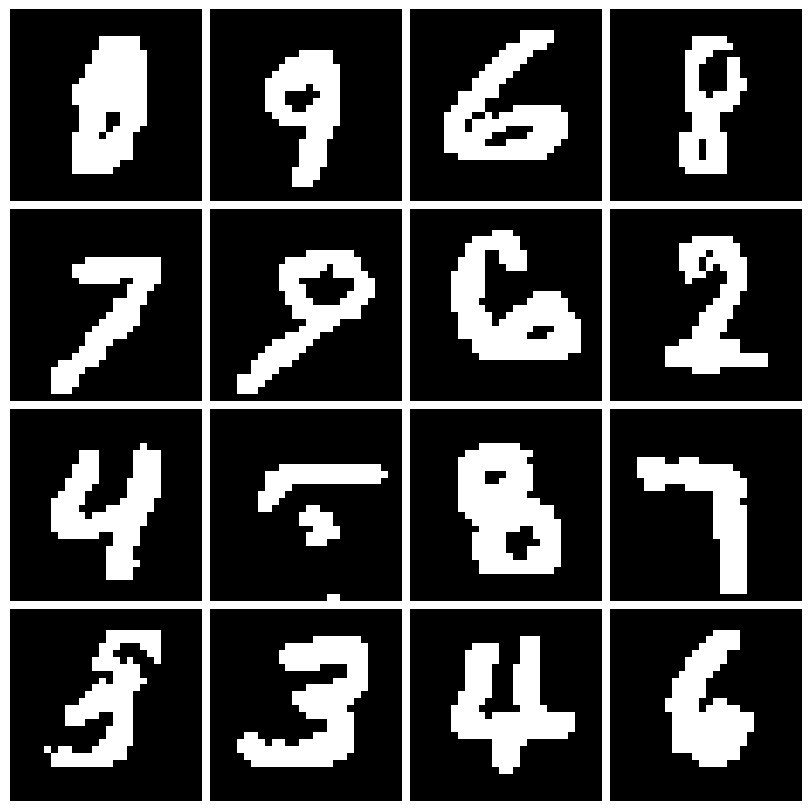

In [ ]:
fig, ax = plt.subplots(4, 4, figsize=(8, 8),  layout='constrained')

for i in range(16):
    ax[i // 4, i % 4].imshow(x_hat.cpu().numpy()[i], cmap='Greys_r')
    ax[i // 4, i % 4].axis('off')

Chúng ta cũng có thể quan sát cách mạng lưới xử lý ảnh tại các thời điểm $t$ khác nhau trong quá trình lấy mẫu để hiểu cách hình ảnh thành hình từ trạng thái không xác định.

In [ ]:
x_0 = get_sample(train_loader)[0][0][0]

Ys = []
Ks = []
Ts = []

# We set t going from 0 to 2/3
for t in np.linspace(0.001, 0.667, 20):
  l, y, k, t_ = bfn.process(x_0[None, :, :, None].to(torch.int64).to(DEVICE), training=False, time=t)
  Ys.append(y.permute(0, 2, 1, 3).cpu().numpy()[0, :, :, 1])
  Ks.append(k.permute(0, 2, 1).cpu().numpy()[0])
  Ts.append(t)

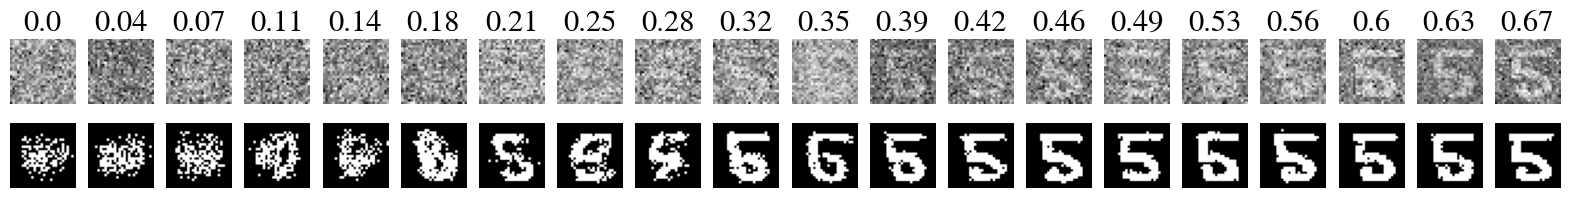

In [ ]:
fig, ax = plt.subplots(2, 20, figsize=(20, 2))

for i in range(20):
  ax[0, i].imshow(Ys[i], cmap='Greys_r')
  ax[1, i].imshow(Ks[i], cmap='Greys_r')
  ax[0, i].axis('off')
  ax[1, i].axis('off')

  ax[0, i].set_title(np.round(Ts[i], 2))

Khi tiến trình diễn ra ($t$ tăng dần), các hình ảnh trở nên rõ nét hơn và cuối cùng hội tụ về các chữ số trông giống như dữ liệu thật trong tập huấn luyện.